In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV ,RandomizedSearchCV,train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
import joblib

In [3]:
df=pd.read_csv("college_student_placement_dataset.csv")
df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [5]:
df = df.drop('College_ID', axis=1)


In [6]:
df['Internship_Experience'].replace({'Yes':1,'No':0},inplace=True)
df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,No
1,97,5.52,5.37,8,0,7,8,0,No
2,109,5.36,5.83,9,0,3,1,1,No
3,122,5.47,5.75,6,1,1,6,1,No
4,96,7.91,7.69,7,0,8,10,2,No
...,...,...,...,...,...,...,...,...,...
9995,119,8.41,8.29,4,0,1,8,0,Yes
9996,70,9.25,9.34,7,0,0,7,2,No
9997,89,6.08,6.25,3,1,3,9,5,No
9998,107,8.77,8.92,3,0,7,5,1,No


In [7]:
df['Placement'].replace({'Yes':1,'No':0},inplace=True)
df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0
...,...,...,...,...,...,...,...,...,...
9995,119,8.41,8.29,4,0,1,8,0,1
9996,70,9.25,9.34,7,0,0,7,2,0
9997,89,6.08,6.25,3,1,3,9,5,0
9998,107,8.77,8.92,3,0,7,5,1,0


In [8]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,0.396400,4.970900,5.561800,2.513400,0.165900
std,15.053101,1.447519,1.470141,2.873477,0.489174,3.160103,2.900866,1.715959,0.372009
min,41.000000,5.000000,4.540000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,0.000000,2.000000,3.000000,1.000000,0.000000
50%,99.000000,7.560000,7.550000,6.000000,0.000000,5.000000,6.000000,3.000000,0.000000
75%,110.000000,8.790000,8.770000,8.000000,1.000000,8.000000,8.000000,4.000000,0.000000
max,158.000000,10.000000,10.460000,10.000000,1.000000,10.000000,10.000000,5.000000,1.000000


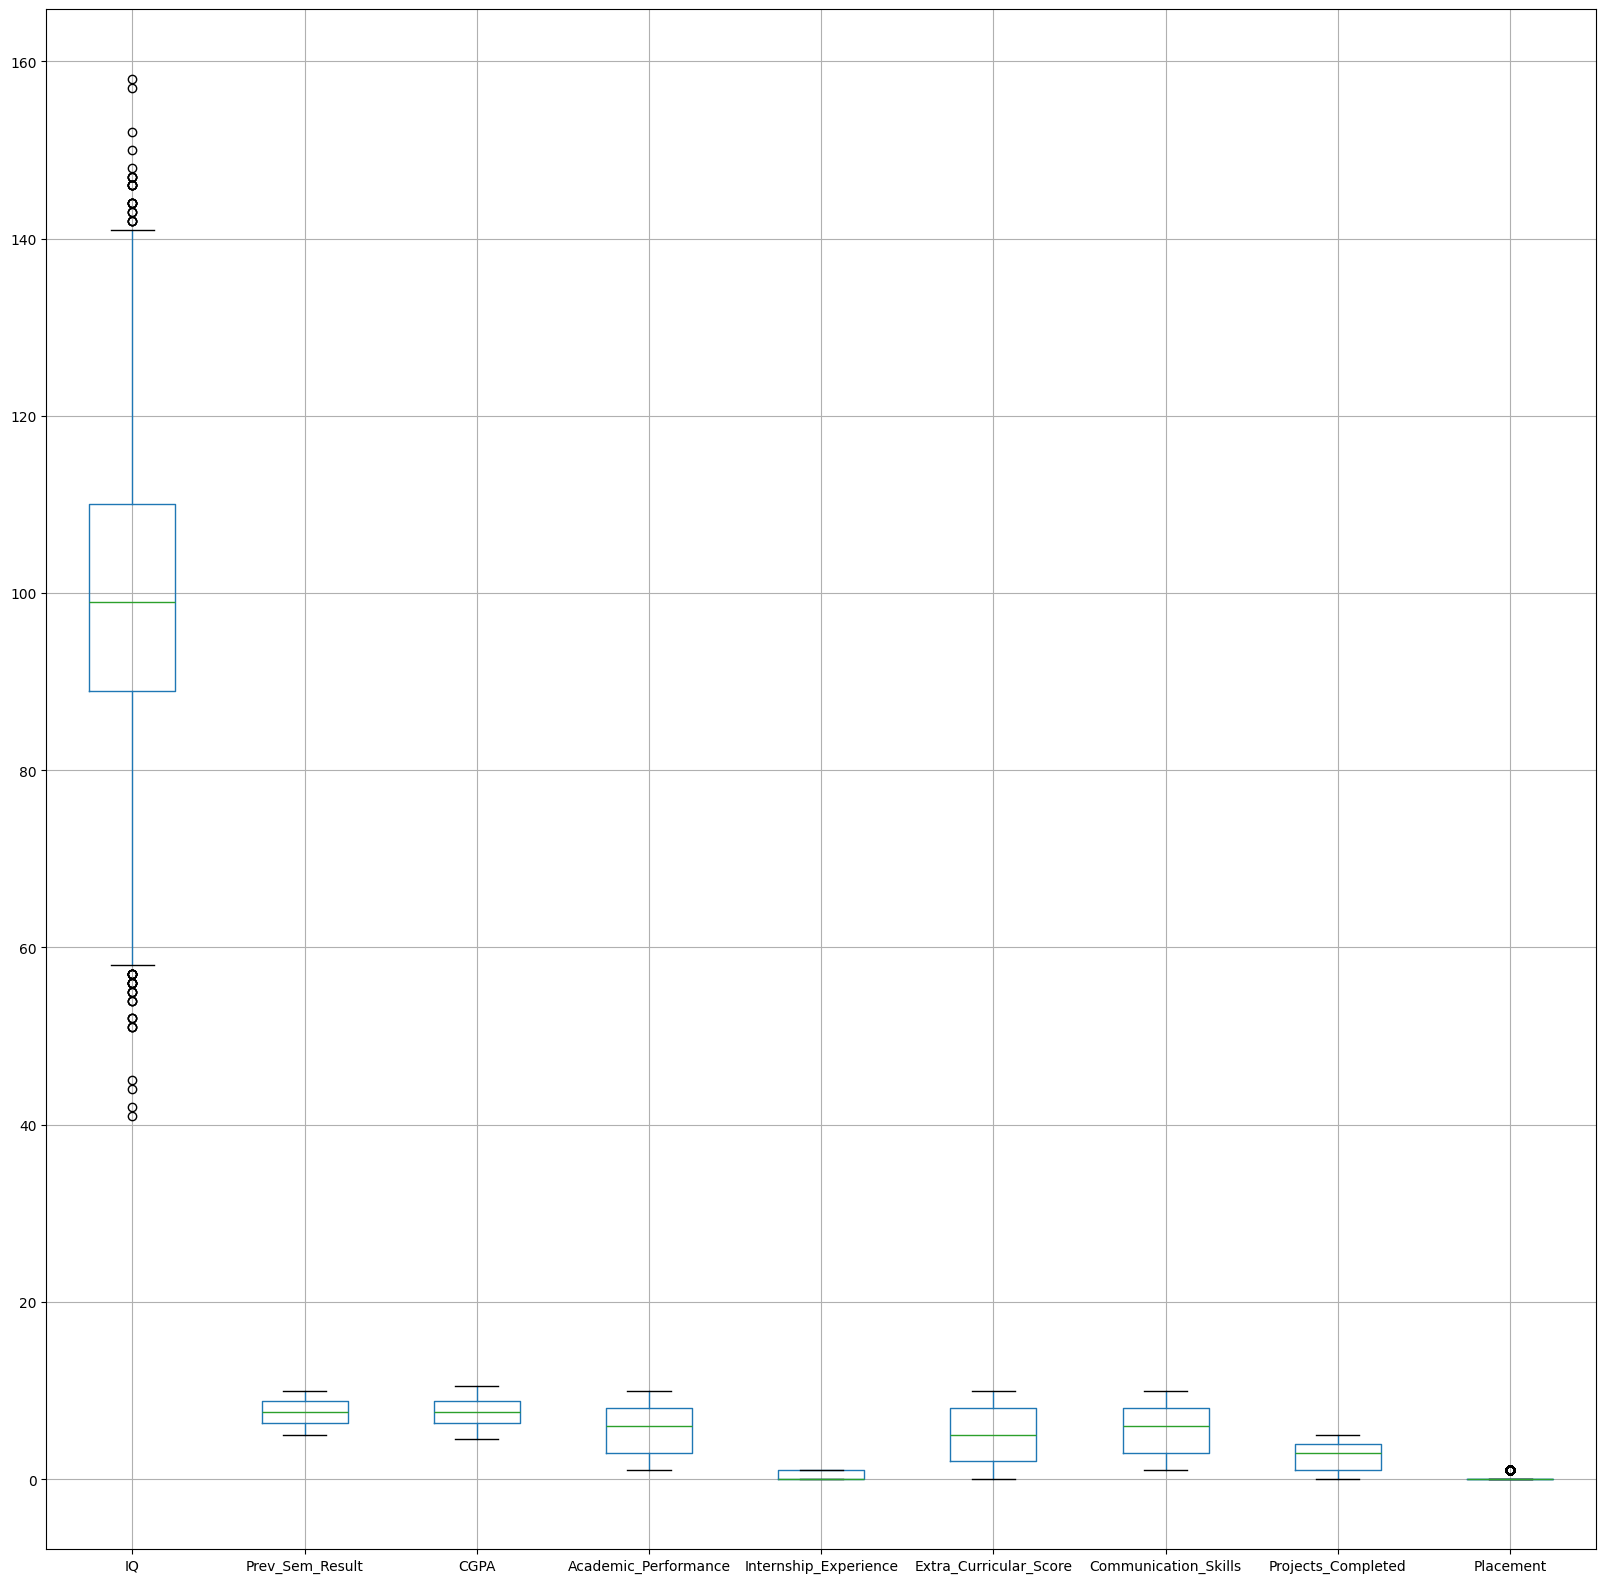

In [9]:

plt.figure(figsize=(20, 20))  
df.boxplot()
plt.show()

In [10]:
## from the above boxplot we can analyse that their are outlier present in iq column

In [11]:
#handling outlier

In [12]:
Q1 = df['IQ'].quantile(0.25)
Q3 = df['IQ'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

median = df['IQ'].median()

for i in range(len(df)):
    if df.loc[i, 'IQ'] < lower_bound or df.loc[i, 'IQ'] > upper_bound:
        df.loc[i, 'IQ'] = median



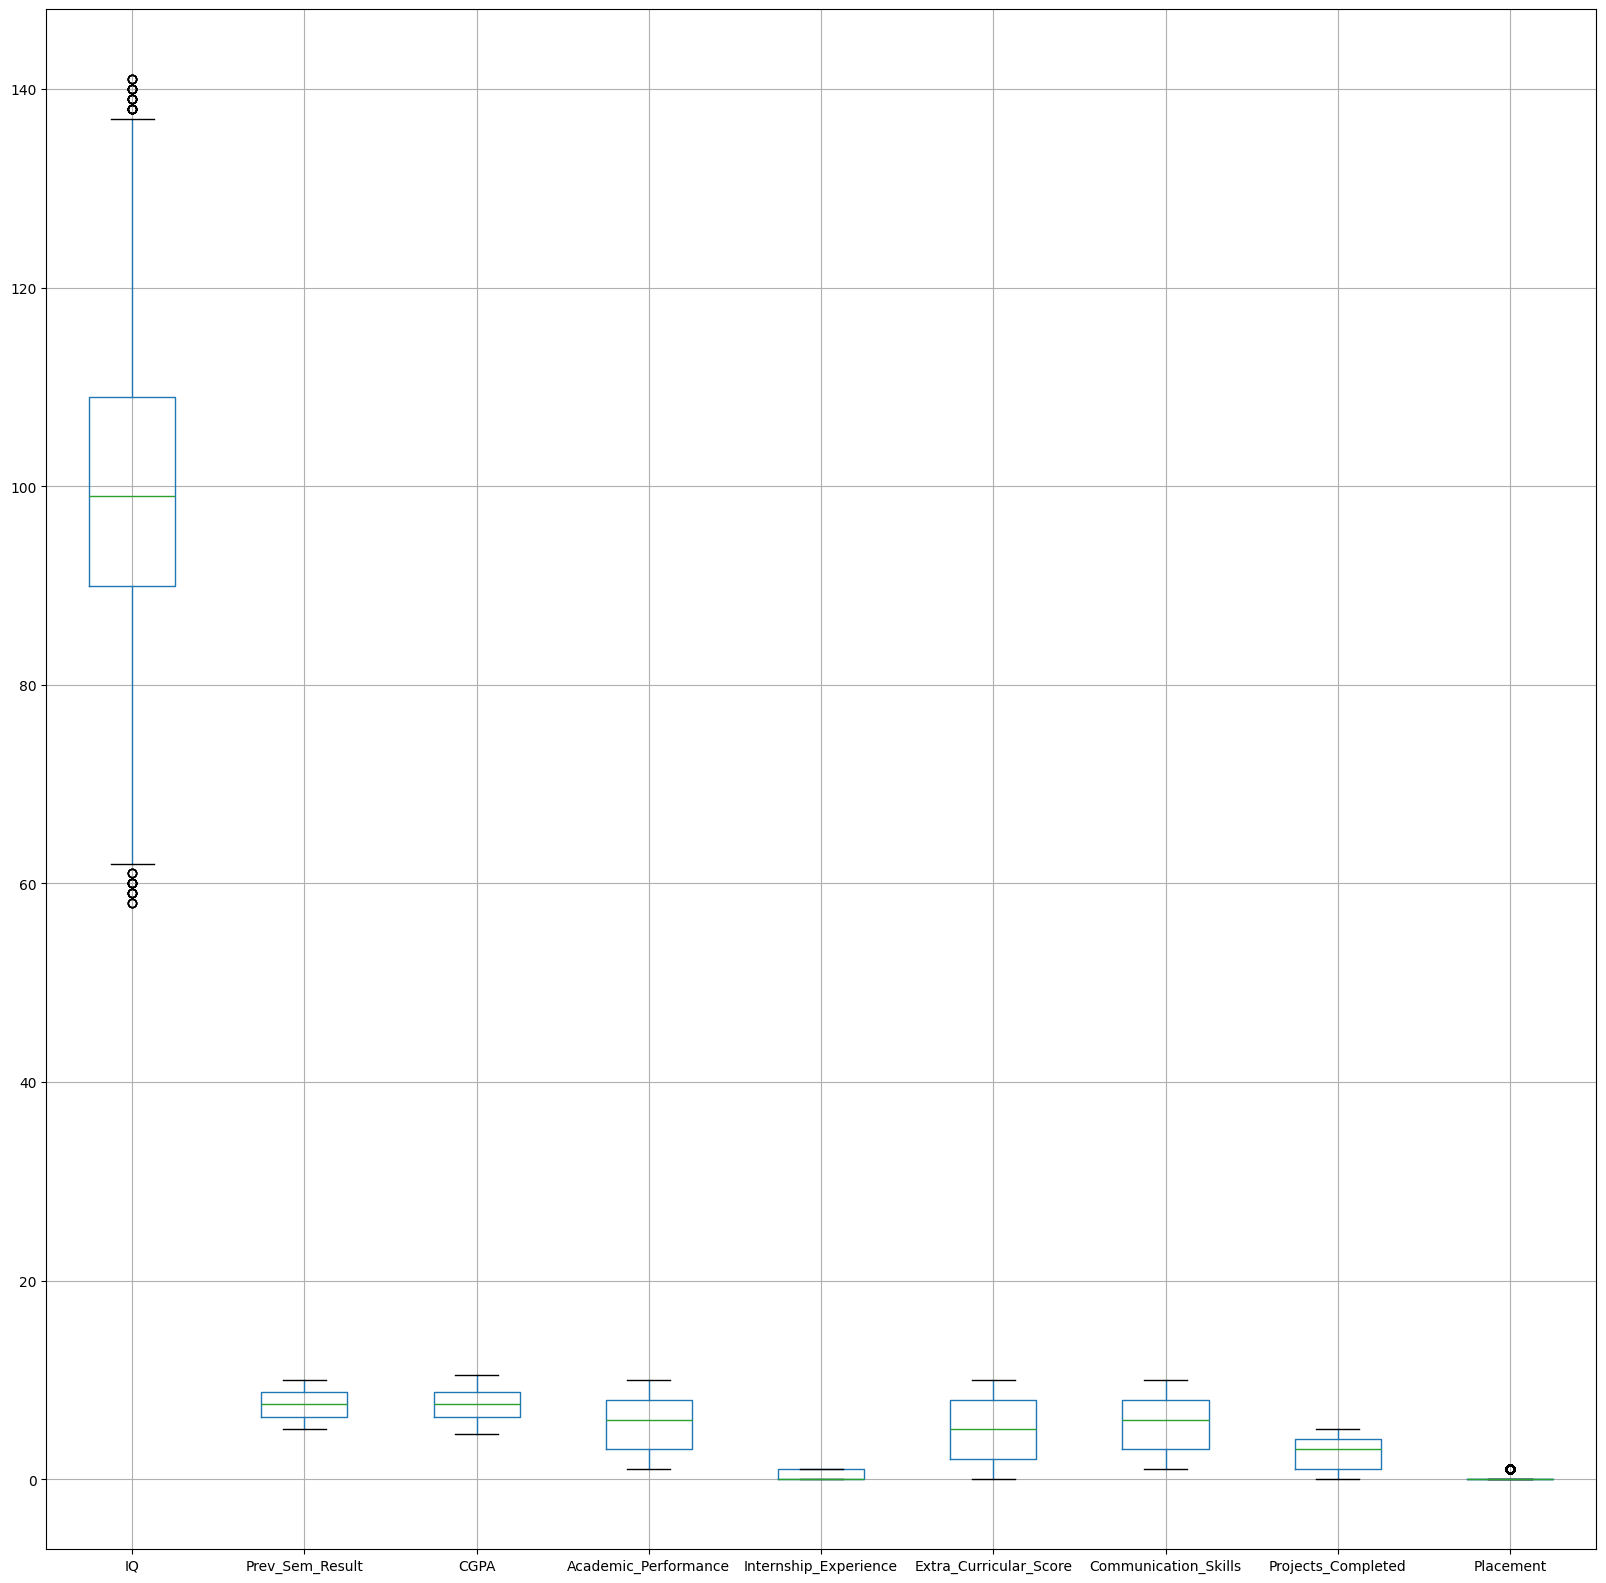

In [13]:
plt.figure(figsize=(20, 20))  
df.boxplot()
plt.show()

In [14]:
corr=df.corr()
corr

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
IQ,1.000000,-0.003321,-0.003336,-0.009664,0.001974,-0.009084,-0.013201,0.016503,0.285124
Prev_Sem_Result,-0.003321,1.000000,0.980768,-0.005765,-0.013347,0.009326,-0.017269,0.018434,0.317896
CGPA,-0.003336,0.980768,1.000000,-0.002958,-0.012562,0.011441,-0.018242,0.020872,0.321607
Academic_Performance,-0.009664,-0.005765,-0.002958,1.000000,0.025903,0.011774,-0.019733,-0.013148,-0.014920
Internship_Experience,0.001974,-0.013347,-0.012562,0.025903,1.000000,0.002093,-0.020437,-0.010260,-0.005841
Extra_Curricular_Score,-0.009084,0.009326,0.011441,0.011774,0.002093,1.000000,0.003769,0.008122,-0.004740
Communication_Skills,-0.013201,-0.017269,-0.018242,-0.019733,-0.020437,0.003769,1.000000,-0.004486,0.323155
Projects_Completed,0.016503,0.018434,0.020872,-0.013148,-0.010260,0.008122,-0.004486,1.000000,0.217499
Placement,0.285124,0.317896,0.321607,-0.014920,-0.005841,-0.004740,0.323155,0.217499,1.000000


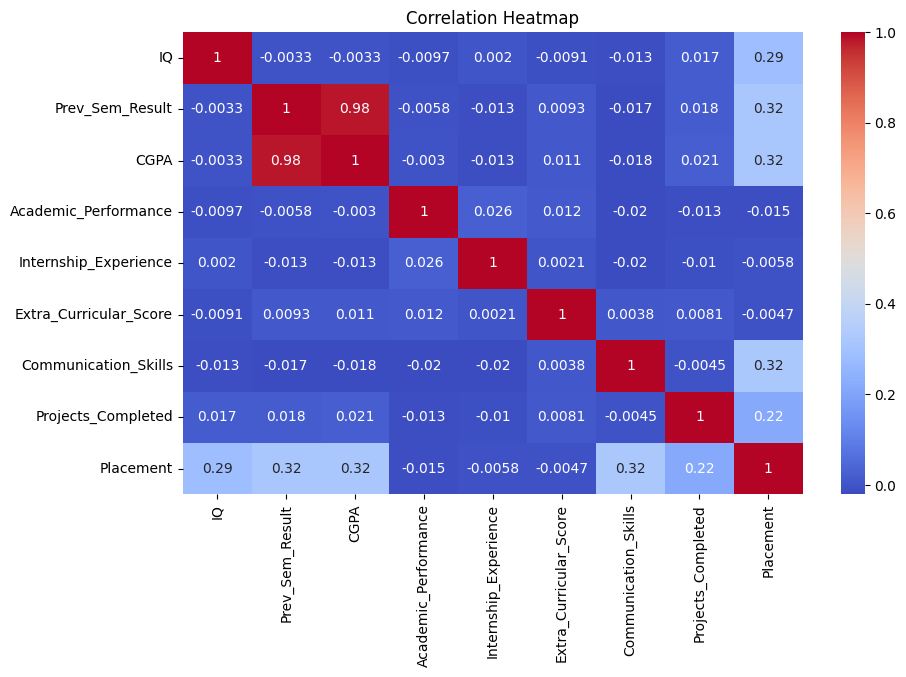

In [15]:
plt.figure(figsize=(10, 6))  
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# strong correlation between cgpa and prev sem_result 
#moderate relation between CGPA and placement 0.32  , Communication_Skills and Placement: 0.32 Prev_Sem_Result and Placement: 0.31
# based on this good predictor can be
# CGPA – 0.32

# Communication_Skills – 0.32

# Prev_Sem_Result – 0.31

# IQ – 0.28

# Projects_Completed – 0.21




In [20]:
x=df.drop('Placement',axis=1)
y=df['Placement']


In [ ]:
###Scaling using standardiztion

In [21]:
std=StandardScaler()
std.fit(x)
std_array=std.transform(x)
x_std=pd.DataFrame(std_array,columns=x.columns)
x_std


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,0.514059,-0.639521,-0.851919,0.853921,-0.810387,0.958593,0.840550,0.866381
1,-0.170431,-1.392572,-1.470939,0.853921,-0.810387,0.642131,0.840550,-1.464794
2,0.650957,-1.503111,-1.158028,1.201949,-0.810387,-0.623713,-1.572644,-0.882000
3,1.540795,-1.427115,-1.212447,0.157865,1.233979,-1.256636,0.151066,-0.882000
4,-0.238880,0.258612,0.107220,0.505893,-0.810387,0.958593,1.530034,-0.299206
...,...,...,...,...,...,...,...,...
9995,1.335448,0.604048,0.515365,-0.538190,-0.810387,-1.256636,0.840550,-1.464794
9996,-2.018556,1.184380,1.229618,0.505893,-0.810387,-1.573097,0.495808,-0.299206
9997,-0.718024,-1.005683,-0.872327,-0.886218,1.233979,-0.623713,1.185292,1.449175
9998,0.514059,0.852762,0.943917,-0.886218,-0.810387,0.642131,-0.193676,-0.882000


In [ ]:
# train test split

In [24]:

x_train, x_test, y_train, y_test = train_test_split(x_std, y, test_size=0.2, random_state=42,stratify=y)


In [ ]:
## model building

In [58]:
knn=KNeighborsClassifier(n_neighbors=2)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=2)

In [59]:
# for tesst
y_pred=knn.predict(x_test)
c_matrix=confusion_matrix(y_test,y_pred)
print("Confusion matrix is\n",c_matrix)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)



Confusion matrix is
 [[1656   12]
 [ 134  198]]
Classification Report :
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      1668
           1       0.94      0.60      0.73       332

    accuracy                           0.93      2000
   macro avg       0.93      0.79      0.84      2000
weighted avg       0.93      0.93      0.92      2000



In [60]:
# for trainig
y_pred=knn.predict(x_train)
c_matrix=confusion_matrix(y_train,y_pred)
print("Confusion matrix is\n",c_matrix)
clf_report = classification_report(y_train, y_pred)
print('Classification Report :\n', clf_report)

Confusion matrix is
 [[6673    0]
 [ 321 1006]]
Classification Report :
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      6673
           1       1.00      0.76      0.86      1327

    accuracy                           0.96      8000
   macro avg       0.98      0.88      0.92      8000
weighted avg       0.96      0.96      0.96      8000



In [61]:
## hyperparameter tuning using randomizedsearchcv as dataset is too large 


In [62]:
knn = KNeighborsClassifier()
h={'n_neighbors':np.arange(2,50),'p':(1,2)}
rscv=RandomizedSearchCV(knn,h,cv=5)
rscv.fit(x_train,y_train)


RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                                        'p': (1, 2)})

In [63]:
rscv.best_estimator_

KNeighborsClassifier(n_neighbors=np.int64(13), p=1)

In [64]:
rscv.best_score_

np.float64(0.944875)

In [65]:
# for tesst
y_pred=rscv.predict(x_test)
c_matrix=confusion_matrix(y_test,y_pred)
print("Confusion matrix is\n",c_matrix)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

Confusion matrix is
 [[1662    6]
 [  93  239]]
Classification Report :
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      1668
           1       0.98      0.72      0.83       332

    accuracy                           0.95      2000
   macro avg       0.96      0.86      0.90      2000
weighted avg       0.95      0.95      0.95      2000



In [66]:
# for trainig
y_pred=rscv.predict(x_train)
c_matrix=confusion_matrix(y_train,y_pred)
print("Confusion matrix is\n",c_matrix)
clf_report = classification_report(y_train, y_pred)
print('Classification Report :\n', clf_report)

Confusion matrix is
 [[6646   27]
 [ 289 1038]]
Classification Report :
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      6673
           1       0.97      0.78      0.87      1327

    accuracy                           0.96      8000
   macro avg       0.97      0.89      0.92      8000
weighted avg       0.96      0.96      0.96      8000



In [67]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rscv, x_std, y, cv=5)
print("CV Accuracy:", cv_scores.mean())


CV Accuracy: 0.9457000000000001


In [69]:
joblib.dump(rscv, 'model_file.pkl')

['model_file.pkl']

In [70]:
joblib.dump(std, 'stdmodel_file.pkl')

['stdmodel_file.pkl']

In [88]:
import gradio as gr

model = joblib.load("model_file.pkl")              
scaler = joblib.load("stdmodel_file.pkl")          

def predict(iq, prev_sem, cgpa, academic_perf, internship, extra_curricular, comm_skills, projects):
    try:
        input_data = np.array([[iq, prev_sem, cgpa, academic_perf, internship, extra_curricular, comm_skills, projects]])
        input_scaled = scaler.transform(input_data)

        prediction = model.predict(input_scaled)[0]
        proba = model.predict_proba(input_scaled)[0]
        confidence = round(max(proba) * 100, 2)

        label = "✅ Yes (Placed)" if prediction == 1 else "❌ No (Not Placed)"
        return f"{label}\n📊 Confidence: {confidence}%"
    
    except Exception as e:
        return f"❌ Error: {str(e)}"

# Gradio Interface
demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="🧠 IQ"),
        gr.Number(label="📘 Previous Semester Result"),
        gr.Number(label="🎓 CGPA"),
        gr.Number(label="📚 Academic Performance (Rate out of 10)"),
        gr.Number(label="💼 Internship Experience (0 = No, 1 = Yes)"),
        gr.Number(label="🎨 Extra-Curricular Score (out of 10)"),
        gr.Number(label="🗣️ Communication Skills (Rate out of 10)"),
        gr.Number(label="💡 Projects Completed"),
    ],
    outputs="text",
    title="🎯 Student Placement Predictor",
    description="Enter your academic profile below to predict placement outcome using a trained KNN model. 🧮",
    theme="soft",  # Options: 'default', 'huggingface', 'soft', 'dark'
)

demo.launch()




* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.
